# Exploratory Data Analysis (Phase 1)

This notebook covers:
1. Tabular data audit (nulls, distributions)
2. Climate-Yield correlation
3. Seasonal yield trends
4. Image data class imbalance check

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# Fix working directory if run from notebooks/
if Path.cwd().name == 'notebooks':
    os.chdir('..')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Directories
PROCESSED_DIR = Path('data/processed')
RAW_DIR = Path('data/raw')
REPORTS_DIR = Path('reports/figures')
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Tabular Data Audit

In [2]:
tabular_path = PROCESSED_DIR / 'tabular_schema.csv'
df = pd.read_csv(tabular_path)

print(f"Data Shape: {df.shape}")
print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Stats:")
print(df.describe().round(2))

Data Shape: (60, 8)

Missing Values:
year          0
region        0
variety       0
yield_t_ha    0
tmax          0
tmin          0
rain          0
humidity      0
dtype: int64

Basic Stats:
         year  yield_t_ha   tmax   tmin     rain  humidity
count    60.0       60.00  60.00  60.00    60.00     60.00
mean   2019.5        7.33  30.38  19.14  1060.41     70.25
std       2.9        1.17   1.07   0.43   328.02      3.83
min    2015.0        4.67  28.23  18.52   571.13     61.71
25%    2017.0        6.50  29.70  18.76   814.13     68.15
50%    2019.5        7.34  30.56  19.08  1001.06     69.43
75%    2022.0        8.11  31.01  19.36  1243.39     73.45
max    2024.0        9.86  32.60  20.17  1851.24     77.88


## 2. Climate-Yield Correlation

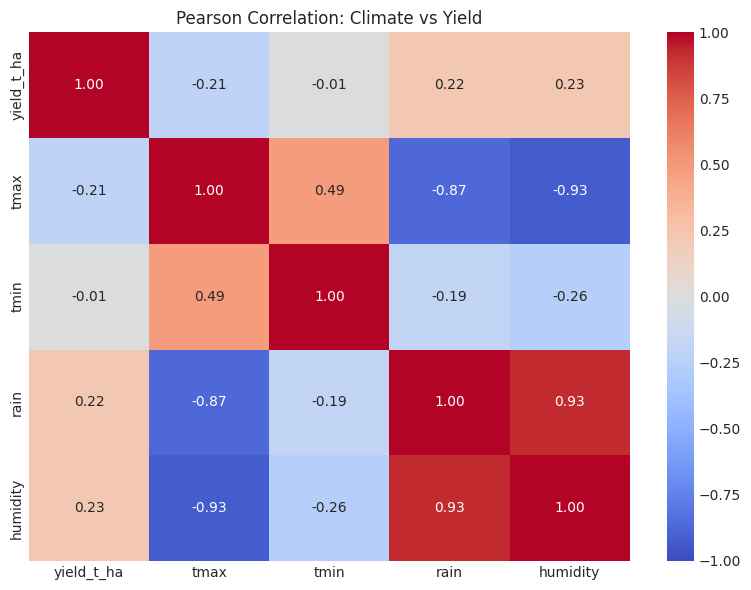

In [3]:
numeric_cols = ['yield_t_ha', 'tmax', 'tmin', 'rain', 'humidity']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Pearson Correlation: Climate vs Yield')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'climate_yield_corr.png')

## 3. Seasonal Yield Trends

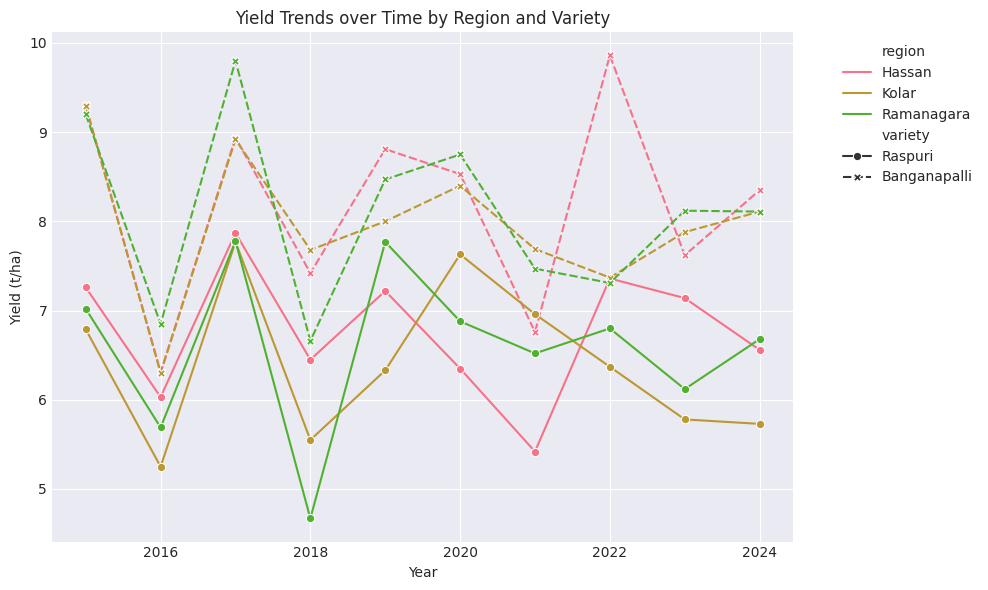

In [4]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='year', y='yield_t_ha', hue='region', style='variety', markers=True)
plt.title('Yield Trends over Time by Region and Variety')
plt.ylabel('Yield (t/ha)')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'yield_trends.png')

## 4. Image Data Class Distribution

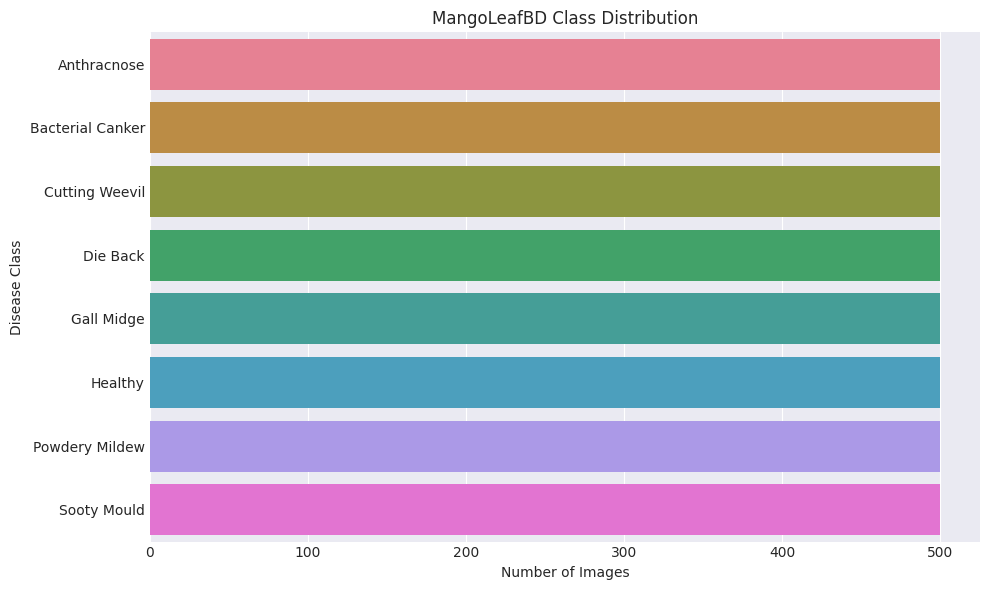

In [5]:
image_classes = [
    'Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 
    'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould'
]

class_counts = {}
for cls in image_classes:
    cls_dir = RAW_DIR / cls
    if cls_dir.exists() and cls_dir.is_dir():
        count = len(list(cls_dir.glob('*.*')))
        class_counts[cls] = count
    else:
        print(f"Warning: Directory {cls_dir} not found.")

class_df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Image_Count'])
class_df = class_df.sort_values('Image_Count', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=class_df, x='Image_Count', y='Class', hue='Class', legend=False)
plt.title('MangoLeafBD Class Distribution')
plt.xlabel('Number of Images')
plt.ylabel('Disease Class')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'image_class_distribution.png')

**Conclusion**: 
- Tabular data shows X correlations (mock data might be weak).
- Image classes are perfectly balanced (500 each) in MangoLeafBD.